# Test of origin of replication deconvolution with fixed offset configs

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [59]:
from src.origins import load_origins

origins = load_origins()
origin = origins[origins.ars_name == 'ARS1120'].iloc[0]
origin

chr                                                                                  11
pos                                                                              612412
strand                                                                                -
footprint_class                                                     g1_and_g2_footprint
nucleosome_shift_class                                                           static
mcm_loading_class                                                            downstream
activation_time                                                                    late
derived_origin_efficiency_from_mcguffee_et_al_2013                               0.7361
acs_sequence                                          TTTTTTTATGTTTTTGGCTCCTAGAGGTGAATA
log2_acs_motif_score                                                            14.0135
ars_name                                                                        ARS1120
ars_start                       

In [60]:
from src.config import load_default_chrom_configs

config1, config2 = load_default_chrom_configs()

In [61]:
from src.combined_chromatin_model import CombinedChromatinModel

combined_model = CombinedChromatinModel(config1=config1, config2=config2)

In [62]:
chrom = origin.chr
mnase_span = origin.pos-500, origin.pos+500
combined_model.load_mnase_span(chrom, mnase_span)

Loading chromosome reads: 11
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 999) to (16, 26, 100)
Loading chromosome reads: 11
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 999) to (15, 26, 100)


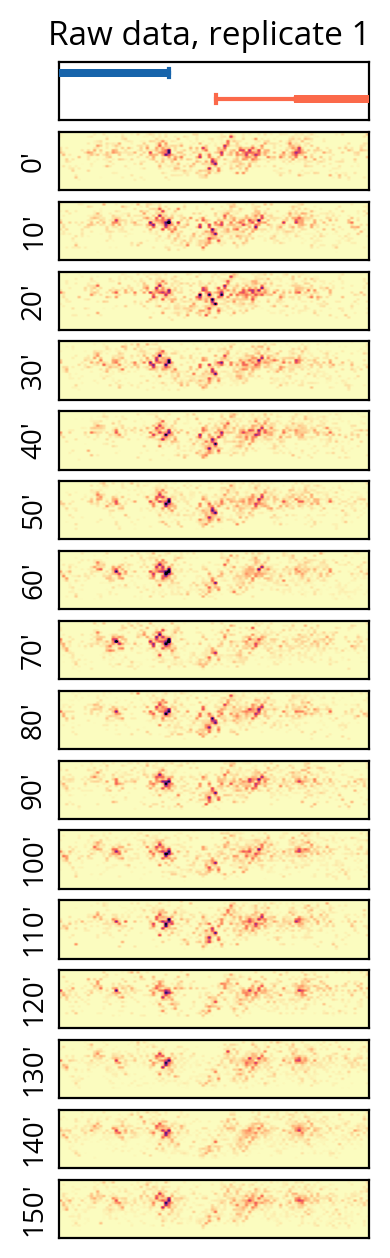

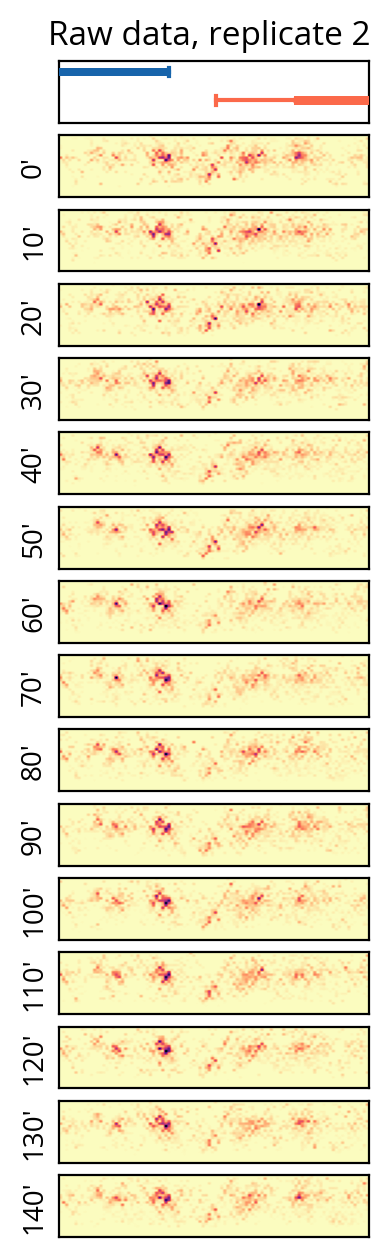

In [63]:
fig = combined_model.chrom1_model.plot_raw_data(figsize=(2, 7))
fig = combined_model.chrom2_model.plot_raw_data(figsize=(2, 7))

In [64]:
combined_model.setup_deconv_model()

Loading copy correction N, Fr, B from output/draft1_run/
todo: Loading prototype replication data from: output/draft1_run/


0/2600 - 00:00:00.000
500/2600 - 00:00:09.913
1000/2600 - 00:01:07.004
1500/2600 - 00:02:08.305
2000/2600 - 00:03:09.934
2500/2600 - 00:04:08.358
Completed - 00:04:14.490


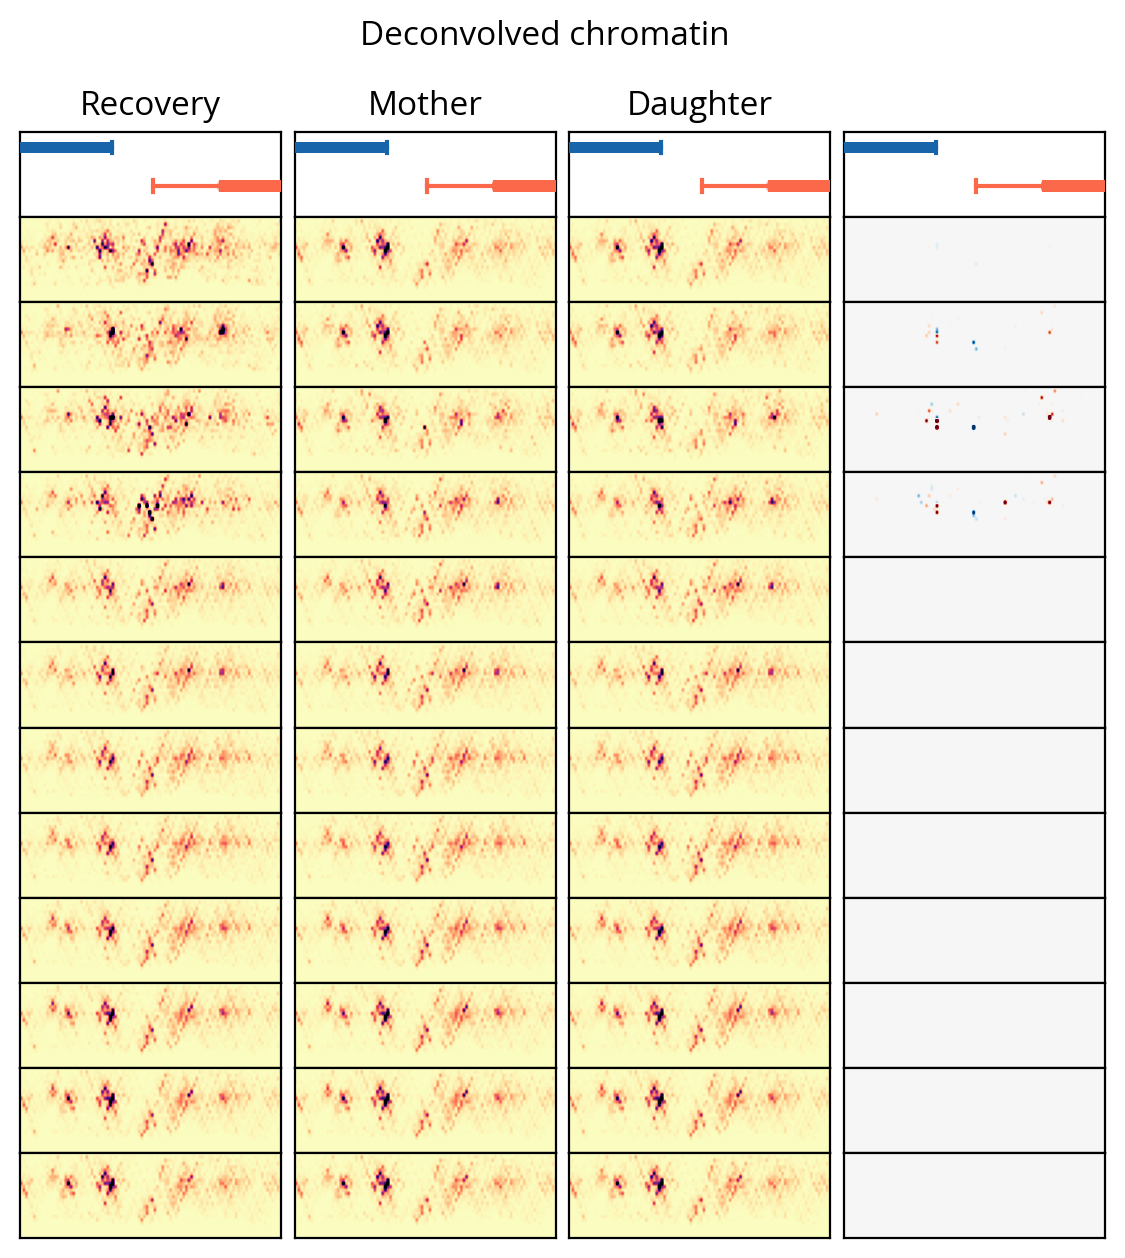

In [65]:
kappa = 0.03
combined_model.deconvolve(gamma=0.01, kappa=kappa, verbose=True)
combined_model.plot_branches(figsize=(7, 7))


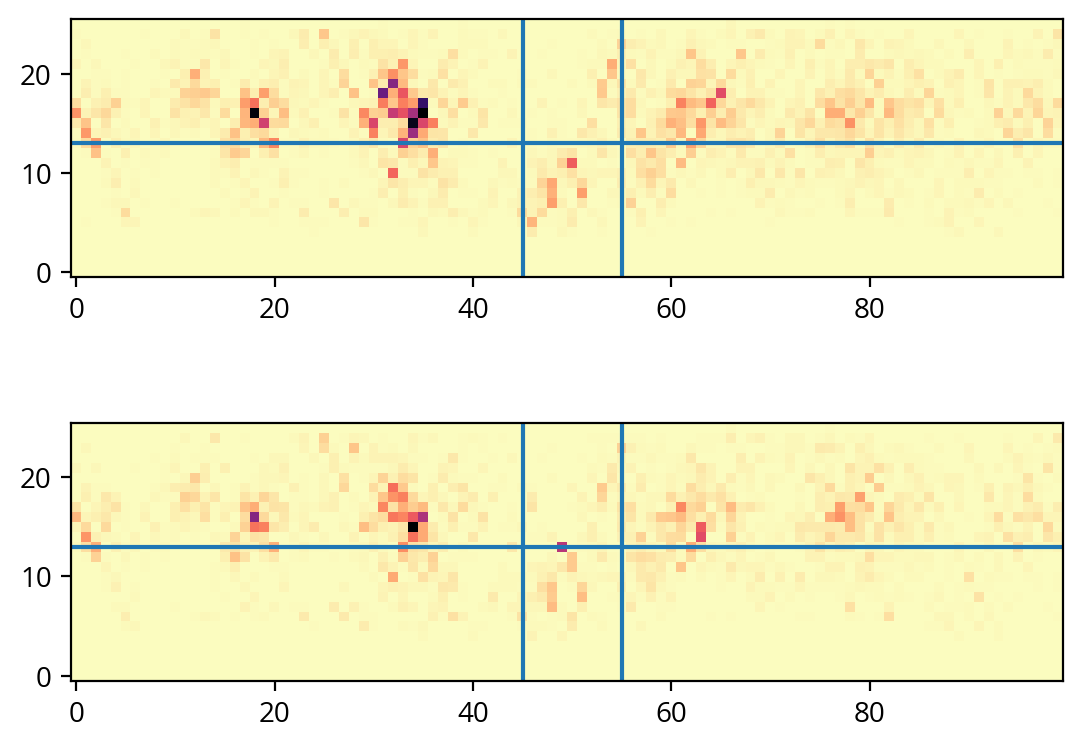

In [81]:
footprint_hspan = 45, 55
footprint_vspan = 0, 13

F_imgs = combined_model.F.reshape((combined_model.F.shape[0], 26, -1))
plt.subplot(2, 1, 1)
plt.imshow(F_imgs[config1.t_indices()[0]], cmap='magma_r', origin='lower')
plt.axvline(footprint_hspan[0])
plt.axvline(footprint_hspan[1])
plt.axhline(footprint_vspan[1])

plt.subplot(2, 1, 2)
plt.imshow(F_imgs[config1.t_indices()[10]], cmap='magma_r', origin='lower')
plt.axvline(footprint_hspan[0])
plt.axvline(footprint_hspan[1])
plt.axhline(footprint_vspan[1])

In [78]:
config1.get_timepoints_for_phase('postG1')

array([ 0.27958474,  1.3727232 ,  2.46586166,  3.55900012,  4.65213857,
        5.74527703,  6.83841549,  7.93155395,  9.02469241, 10.11783087,
       11.21096933, 12.30410778, 13.39724624, 14.4903847 , 15.58352316,
       16.67666162, 17.76980008, 18.86293854, 19.95607699, 21.04921545,
       22.14235391, 23.23549237, 24.32863083, 25.42176929, 26.51490775,
       27.6080462 , 28.70118466, 29.79432312, 30.88746158, 31.98060004,
       33.0737385 , 34.16687696, 35.26001541, 36.35315387, 37.44629233,
       38.53943079, 39.63256925, 40.72570771, 41.81884617, 42.91198462,
       44.00512308, 45.09826154])

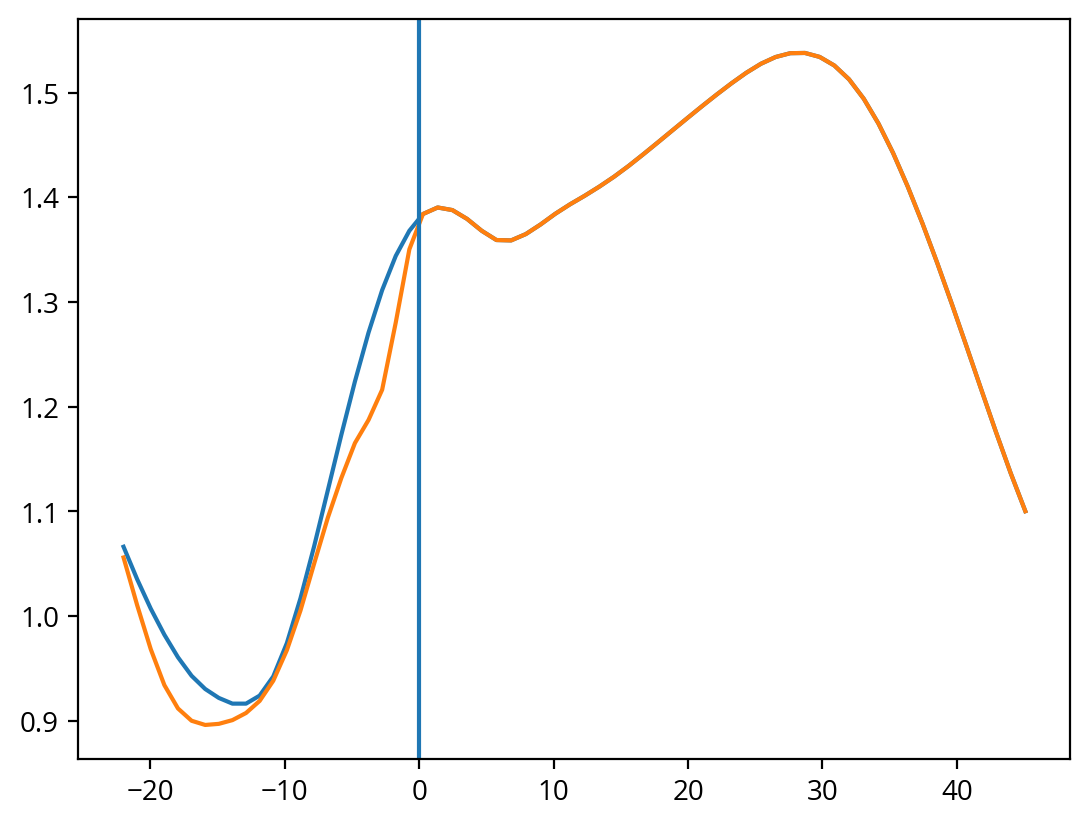

In [82]:
t_tps = config1.get_timepoints_for_branch('t')
b_tps = config1.get_timepoints_for_branch('b')
plt.plot(t_tps, F_imgs[config1.t_indices(), footprint_vspan[0]:footprint_vspan[1]:,
    footprint_hspan[0]:footprint_hspan[1]].mean((1, 2)))
plt.plot(t_tps, F_imgs[config1.b_indices(), footprint_vspan[0]:footprint_vspan[1]:,
    footprint_hspan[0]:footprint_hspan[1]].mean((1, 2)))
plt.axvline(0)
#plt.ylim(0, 2)

(31, 1)

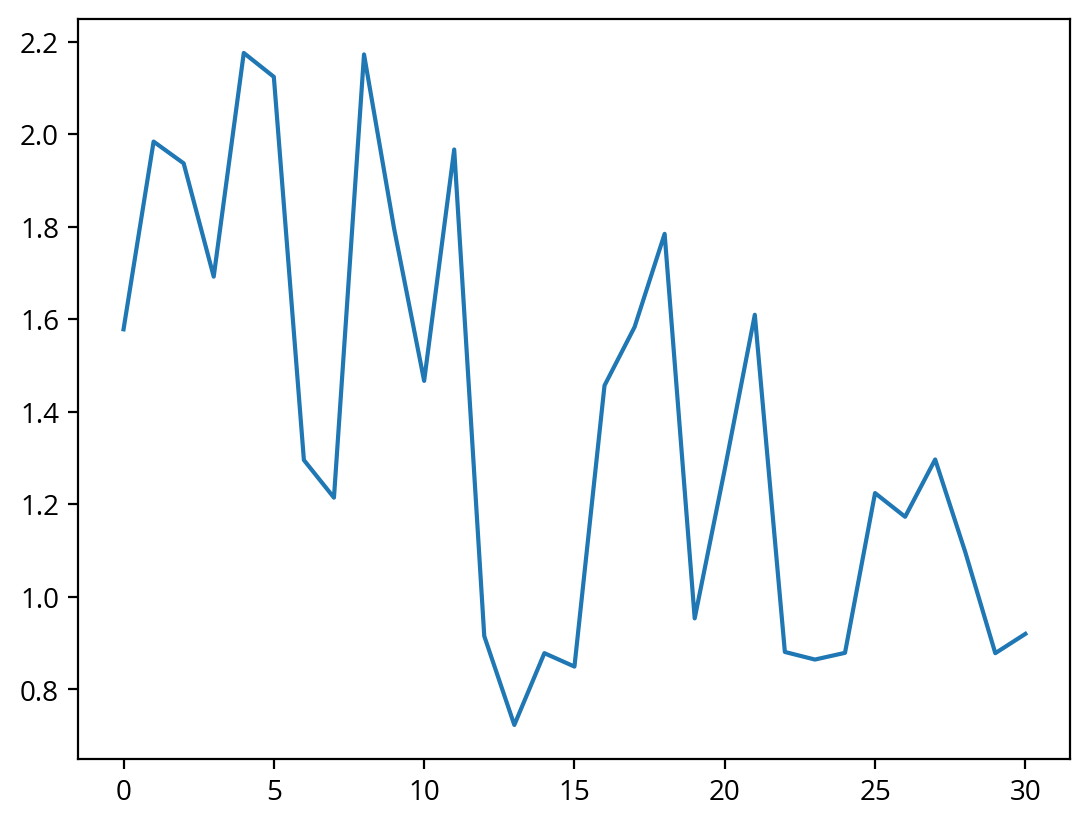

In [87]:
# Looking at these origin occupancy curves, it is worth exploring different values of 
# alpha to identify if we can tune it properly to this signal. With the expectation
# that origin binding should be lowest at the start of G1.
# currently alpha is set to 22, and 20 minutes
#
# ~34% into the cell cycle for the mother branch.
#

# Load the G images for the replicate, take the sum and deconvolve the singular value
origin_G = combined_model.G
G_imgs = combined_model.G.reshape((origin_G.shape[0], 26, -1))

selected_origin_occupancy_G = G_imgs[:, footprint_vspan[0]:footprint_vspan[1]:,
    footprint_hspan[0]:footprint_hspan[1]]
mean_origin_occ = selected_origin_occupancy_G.mean((1, 2))[:, None]

plt.plot(mean_origin_occ)
mean_origin_occ.shape


In [117]:
# Let's try to modify H
config1_alpha_adjusted, config2_alpha_adjusted = load_default_chrom_configs()

config1_alpha_adjusted.modify_alpha(18)
config2_alpha_adjusted.modify_alpha(16)

modified_H = np.concatenate([config1_alpha_adjusted.H, 
                             config2_alpha_adjusted.H])


In [130]:
solver = combined_model.solver

def deconvolve_origin_with_alphas(solver, alphas, config1_alpha_adjusted, 
    config2_alpha_adjusted):
    config1_alpha_adjusted.modify_alpha(alphas[0])
    config2_alpha_adjusted.modify_alpha(alphas[1])

    modified_H = np.concatenate([config1_alpha_adjusted.H, 
                                 config2_alpha_adjusted.H])


    solver.G = selected_origin_occupancy_G.reshape((origin_G.shape[0], -1))
    solver.H = modified_H

    res = solver.deconvolve_G_iteratively(gamma=0.01, kappa=0.03, verbose=True)

    plt.figure(figsize=(4, 2))
    plt.plot(t_tps, res.mean(1)[config1.t_indices()])
    plt.plot(t_tps, res.mean(1)[config1.b_indices()])
    plt.axvline(0, c='black', ls='dotted', lw=0.5)
    plt.title(f"Selected origin occupancy, alphas={alphas}")

    return res


In [131]:
alphas_sweep = [(0, 0),
                (11, 10),
                (16, 14),
                (18, 16),
                (22, 20),
                (26, 24)]

0/130 - 00:00:00.000
Completed - 00:00:11.775
0/130 - 00:00:00.000
Completed - 00:00:11.878
0/130 - 00:00:00.000
Completed - 00:00:11.789
0/130 - 00:00:00.000
Completed - 00:00:11.683
0/130 - 00:00:00.000
Completed - 00:00:11.695
0/130 - 00:00:00.000
Completed - 00:00:12.203


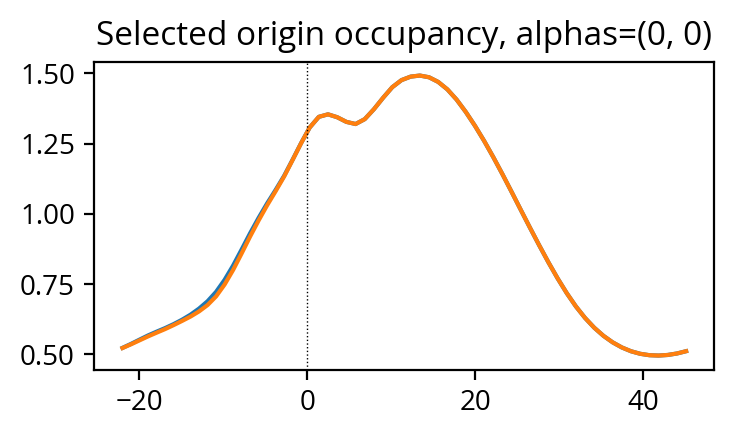

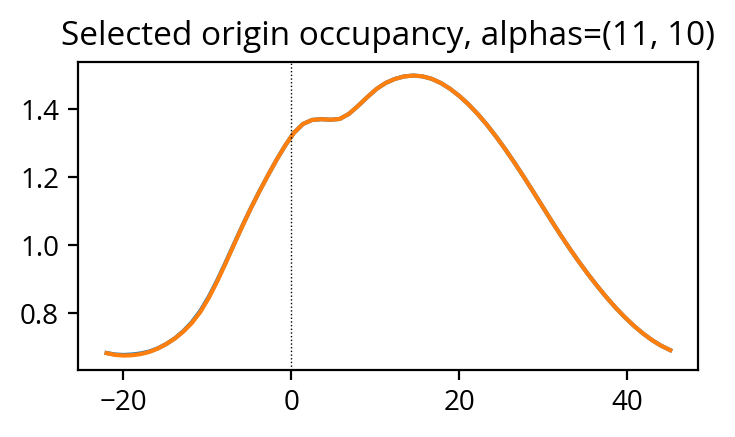

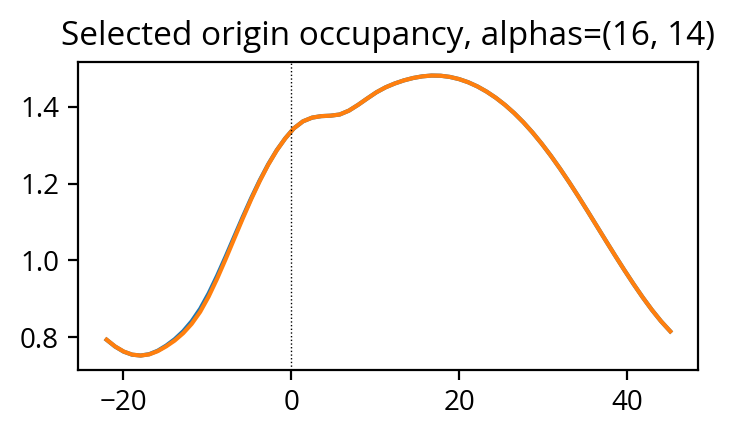

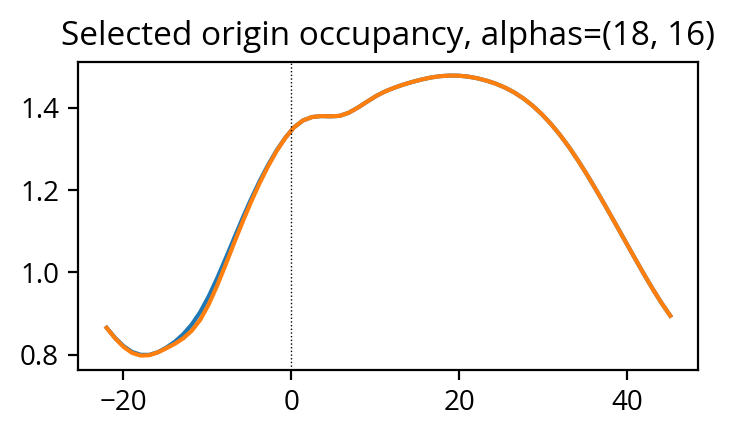

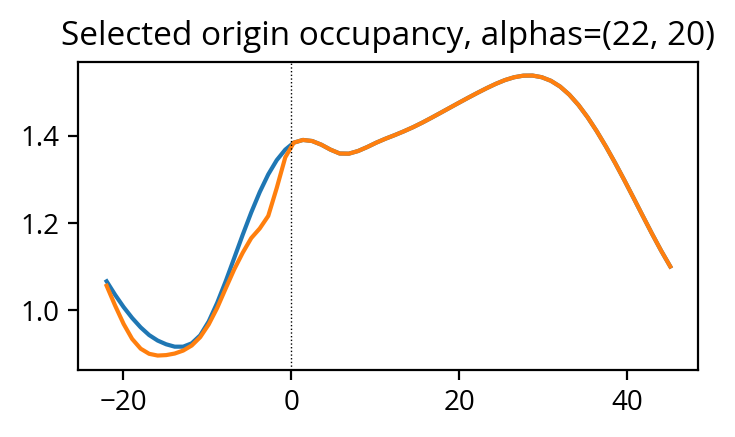

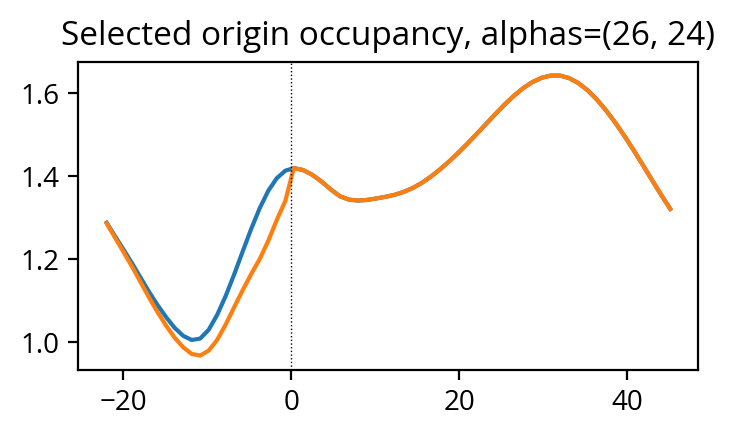

In [132]:
for alphas in alphas_sweep:
    res = deconvolve_origin_with_alphas(solver, alphas, config1_alpha_adjusted,
                                       config2_alpha_adjusted)
